# Load & Inspect Data

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/house_prices.csv")

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


## Dataset Information & Missing Values Analysis

In [3]:
df.info()

print("\n--- Summary Statistics ---")
display(df.describe())

print("\n--- Missing Values Percentage (%) ---")
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct)

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN



--- Missing Values Percentage (%) ---


Plot Area            100.000000
Dimensions           100.000000
Society               58.485264
Super Area            57.422506
Car Parking           55.114621
overlooking           43.425354
Carpet Area           43.018488
facing                37.451408
Ownership             34.936624
Balcony               26.094352
Price (in rupees)      9.419776
Floor                  3.773776
Description            1.612000
Furnishing             1.544811
Bathroom               0.441527
Status                 0.327946
Transaction            0.044259
Amount(in rupees)      0.000000
Title                  0.000000
Index                  0.000000
location               0.000000
dtype: float64

### Data Inspection Summary
* **Total Rows:** 187,531 | **Total Columns:** 21
* **Numeric Columns:** Index, Price (in rupees), Dimensions, Plot Area
* **Text / Categorical Columns:** Title, Description, Amount(in rupees), location, Carpet Area, Status, Floor, Transaction, Furnishing, facing, overlooking, Society, Bathroom, Balcony, Car Parking, Ownership, Super Area

## EDA 1: Target Price Distribution

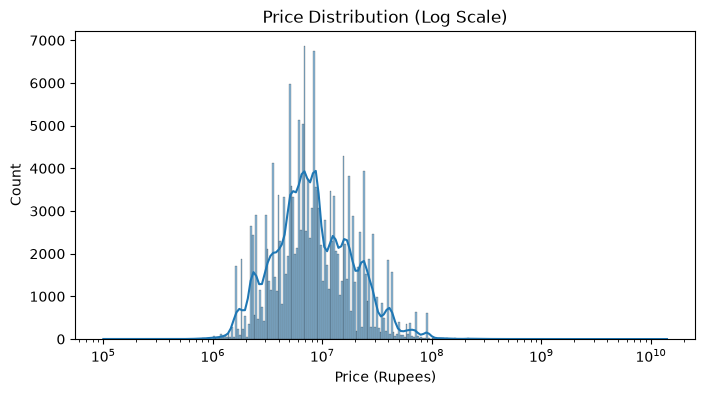

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df_clean_price = df.dropna(subset=["price_clean"])

plt.figure(figsize=(8, 4))
sns.histplot(df_clean_price["price_clean"], log_scale=True, kde=True)
plt.title("Price Distribution (Log Scale)")
plt.xlabel("Price (Rupees)")
plt.ylabel("Count")
plt.show()

**Insight:** House prices are right-skewed across several orders of magnitude. Using a log transformation standardizes the target distribution for regression.

## EDA 2: Price vs. Carpet Area

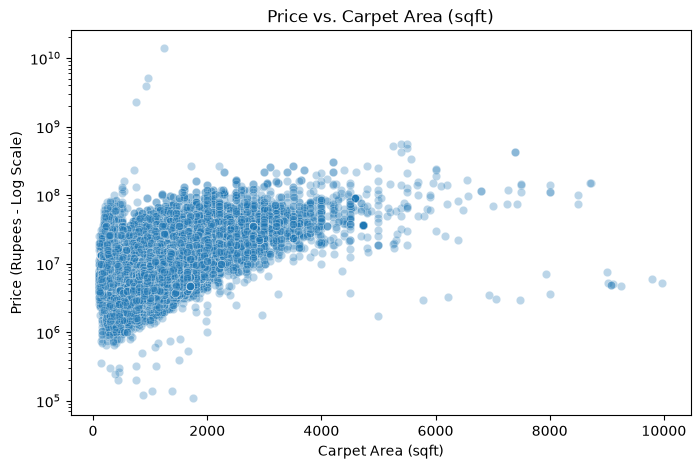

In [5]:
import re

def extract_sqft(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    match = re.search(r"([\d\.]+)\s*(sqft|sqm)?", x)
    if match:
        val = float(match.group(1))
        unit = match.group(2)
        if unit == "sqm":
            return val * 10.764
        return val
    return None

df_clean_price["carpet_area_sqft"] = df_clean_price["Carpet Area"].apply(extract_sqft)
df_area = df_clean_price.dropna(subset=["carpet_area_sqft"])
df_area = df_area[(df_area["carpet_area_sqft"] > 100) & (df_area["carpet_area_sqft"] < 10000)]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_area, x="carpet_area_sqft", y="price_clean", alpha=0.3)
plt.yscale("log")
plt.title("Price vs. Carpet Area (sqft)")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (Rupees - Log Scale)")
plt.show()

**Insight:** There is a strong positive correlation between carpet area and house price. A few extreme outliers exist with very high prices relative to area.

## EDA 3: Average Price by Top-15 Locations

C:\Users\M lapan\AppData\Local\Temp\ipykernel_10632\3301841559.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_loc.values, y=avg_price_loc.index, palette="viridis")


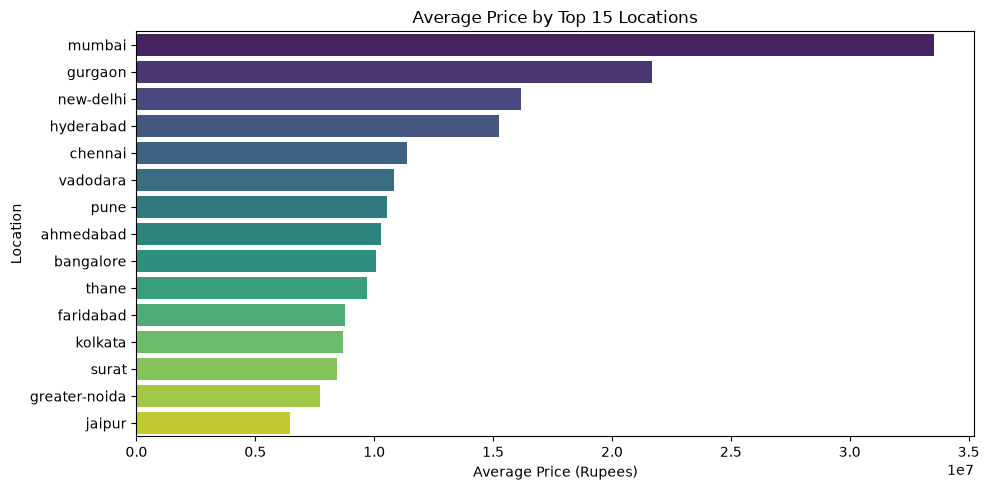

In [6]:
top_15_locs = df_clean_price["location"].value_counts().head(15).index
df_top_locs = df_clean_price[df_clean_price["location"].isin(top_15_locs)]
avg_price_loc = df_top_locs.groupby("location")["price_clean"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=avg_price_loc.values, y=avg_price_loc.index, palette="viridis")
plt.title("Average Price by Top 15 Locations")
plt.xlabel("Average Price (Rupees)")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

**Insight:** Location significantly impacts house prices, with major metropolitan areas like Mumbai, Gurgaon, and New Delhi commanding the highest average property values.

## EDA 4: Price Distribution by Furnishing Status

C:\Users\M lapan\AppData\Local\Temp\ipykernel_10632\2209469165.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean_price, x="Furnishing", y="price_clean", palette="Set2")


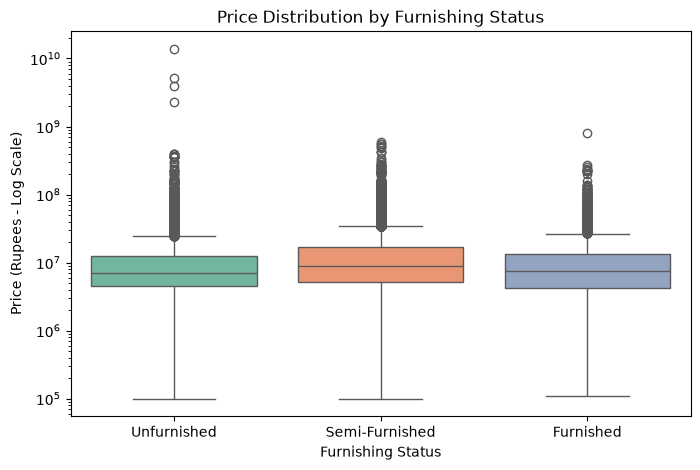

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean_price, x="Furnishing", y="price_clean", palette="Set2")
plt.yscale("log")
plt.title("Price Distribution by Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Price (Rupees - Log Scale)")
plt.show()

**Insight:** Furnishing status shows moderate price variation, with Semi-Furnished and Furnished properties having slightly higher median prices compared to Unfurnished properties.

# Cleaning & Feature Engineering

In [8]:
import re

df_clean = df.copy()

# 1. Parse Price
df_clean["price_clean"] = df_clean["Amount(in rupees)"].apply(parse_amount)
df_clean = df_clean.dropna(subset=["price_clean"])

# 2. Extract Area (sqft)
df_clean["carpet_area_sqft"] = df_clean["Carpet Area"].apply(extract_sqft)

# 3. Extract Floor Number
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    if "ground" in x or "basement" in x:
        return 0
    match = re.search(r"(\d+)", x)
    if match:
        return int(match.group(1))
    return None

df_clean["floor_num"] = df_clean["Floor"].apply(parse_floor)

# 4. Clean Numeric Columns (Bathroom & Balcony)
def parse_numeric(x):
    if not isinstance(x, str):
        return None
    match = re.search(r"(\d+)", x)
    return float(match.group(1)) if match else None

df_clean["bathroom"] = df_clean["Bathroom"].apply(parse_numeric)
df_clean["balcony"] = df_clean["Balcony"].apply(parse_numeric)

# 5. Group Location (Top 50 + 'other')
top_locations = df_clean["location"].value_counts().head(50).index
df_clean["location_grouped"] = df_clean["location"].apply(lambda x: x if x in top_locations else "other")

# 6. Outlier Removal (Price per sqft between 1st and 99th percentile)
df_clean = df_clean.dropna(subset=["carpet_area_sqft"])
df_clean["price_per_sqft"] = df_clean["price_clean"] / df_clean["carpet_area_sqft"]

p_low = df_clean["price_per_sqft"].quantile(0.01)
p_high = df_clean["price_per_sqft"].quantile(0.99)

df_clean = df_clean[(df_clean["price_per_sqft"] >= p_low) & (df_clean["price_per_sqft"] <= p_high)]

print("Cleaned Dataset Shape:", df_clean.shape)
df_clean[["carpet_area_sqft", "floor_num", "bathroom", "balcony", "location_grouped", "price_clean"]].head()

Cleaned Dataset Shape: (99968, 28)


,carpet_area_sqft,floor_num,bathroom,balcony,location_grouped,price_clean
0,500.0,10.0,1.0,2.0,thane,4200000.0
1,473.0,3.0,2.0,NaN,thane,9800000.0
2,779.0,10.0,2.0,NaN,thane,14000000.0
3,530.0,1.0,1.0,1.0,thane,2500000.0
4,635.0,20.0,2.0,NaN,thane,16000000.0


### Cleaning & Feature Engineering Summary
* **Final Rows:** 99,968
* **Engineered Features:** `price_clean`, `carpet_area_sqft`, `floor_num`, `bathroom`, `balcony`, `location_grouped`
* **Outliers Removed:** Filtered using 1st and 99th percentiles on `price_per_sqft`.

# Preprocessing & Baseline Model (Linear Regression)

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony", "location_grouped", "Furnishing", "Transaction"]
X = df_clean[features]
y = np.log1p(df_clean["price_clean"])

num_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
cat_features = ["location_grouped", "Furnishing", "Transaction"]

num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_transformer, num_features),
    ("cat", cat_transformer, cat_features)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model 1: Linear Regression (Baseline)

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print(f"Linear Regression Log RMSE: {lr_rmse:.4f}")
print(f"Linear Regression R2 Score: {lr_r2:.4f}")

Linear Regression Log RMSE: 0.3936
Linear Regression R2 Score: 0.7849


## Model 2: Random Forest Regressor

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest Log RMSE: {rf_rmse:.4f}")
print(f"Random Forest R2 Score: {rf_r2:.4f}")

Random Forest Log RMSE: 0.2000
Random Forest R2 Score: 0.9445


## Models Comparison

In [12]:
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "Log RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

display(comparison_df)

,Model,Log RMSE,R2 Score
0,Linear Regression,0.393649,0.784904
1,Random Forest Regressor,0.200026,0.944462


# Detailed Model Evaluation

## Metrics Report for Linear Regression

In [13]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

lr_pred = lr_pipeline.predict(X_test)

print("--- Linear Regression Metrics ---")
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE:", root_mean_squared_error(y_test, lr_pred))
print("R²  :", r2_score(y_test, lr_pred))

--- Linear Regression Metrics ---
MAE : 0.30701478940691734
RMSE: 0.39364898393799125
R²  : 0.7849043587159097


## Metrics Report for Random Forest Regressor

In [14]:
rf_pred = rf_pipeline.predict(X_test)

print("--- Random Forest Regressor Metrics ---")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", root_mean_squared_error(y_test, rf_pred))
print("R²  :", r2_score(y_test, rf_pred))

--- Random Forest Regressor Metrics ---
MAE : 0.08999283900584296
RMSE: 0.20002629443008968
R²  : 0.9444623474241569


## Predicted vs. Actual Scatter Plot

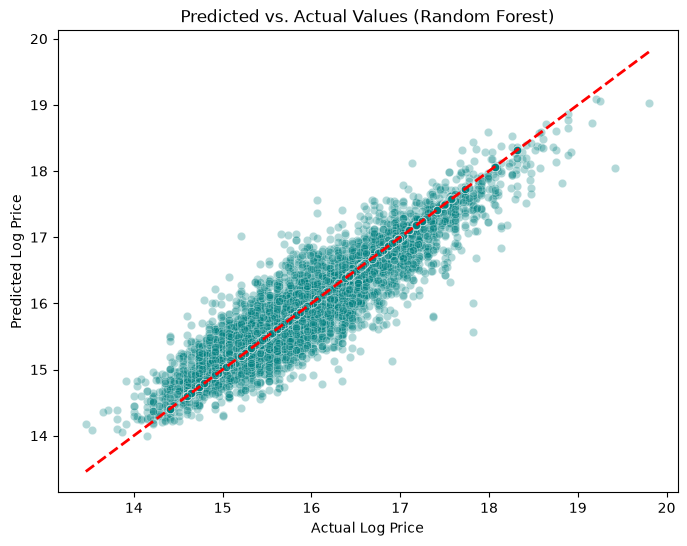

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=rf_pred, alpha=0.3, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Predicted vs. Actual Values (Random Forest)")
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.show()

## Comprehensive Comparison Table

In [16]:
import pandas as pd

eval_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [mean_absolute_error(y_test, lr_pred), mean_absolute_error(y_test, rf_pred)],
    "RMSE": [root_mean_squared_error(y_test, lr_pred), root_mean_squared_error(y_test, rf_pred)],
    "R² Score": [r2_score(y_test, lr_pred), r2_score(y_test, rf_pred)]
})

display(eval_df)

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.307015,0.393649,0.784904
1,Random Forest Regressor,0.089993,0.200026,0.944462


### Winner Selection & Justification
The **Random Forest Regressor** is chosen as the final model because it achieves a substantially higher variance explanation ($R^2 = 0.944$) and significantly lower prediction error metrics ($MAE = 0.090$, $RMSE = 0.200$) compared to Linear Regression ($R^2 = 0.785$, $MAE = 0.307$, $RMSE = 0.394$). Its non-linear decision trees capture complex interactions between property location, carpet area, and amenities far better than a basic linear model.

## 5-Fold Cross-Validation

In [17]:
from sklearn.model_selection import cross_val_score

rf_cv_scores = cross_val_score(rf_pipeline, X, y, cv=5, scoring="r2", n_jobs=-1)

print("5-Fold Cross-Validation R² Scores:", rf_cv_scores)
print(f"Mean R² Score: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std() * 2:.4f})")

5-Fold Cross-Validation R² Scores: [0.61868069 0.59601212 0.80213426 0.94662218 0.34309243]
Mean R² Score: 0.6613 (+/- 0.4085)


# Export the Model & Artifacts

## 1. Save and Verify Model Pipeline

In [18]:
import joblib

joblib.dump(rf_pipeline, "house_price.pkl")

loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))

Reloaded prediction: [15.83041371]


## 2. Export Locations List for Frontend Dropdown

In [19]:
import json

locations_list = sorted(df_clean["location_grouped"].unique().tolist())
json.dump(locations_list, open("locations.json", "w"))

print("Exported", len(locations_list), "unique locations to locations.json")

Exported 51 unique locations to locations.json


## 3. Check Scikit-Learn Version Pinning

In [20]:
import sklearn

print("Installed scikit-learn version:", sklearn.__version__)

Installed scikit-learn version: 1.9.0
